In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from tqdm import tqdm
import os
import yaml
import zuko

from helpers.data_transforms import preprocess_data, inverse_preprocess_data, load_in_data

from helpers.models.DNN import count_parameters
from helpers.evaluation import run_eval_suite_BDTs, run_eval_suite_R
from helpers.plotting import plot_hists_1d, plot_corner_hist_2d, make_2d_plots
from helpers.material_map import apply_material_map_hybrid, build_masked_datasets
from helpers.flow import build_z_lookup, snap_z_to_detector

plt.style.use("../science.mplstyle")

In [3]:
BIN_BOUND = 5
NUM_BINS = 200
NUM_FEATURES = 5
num_BDTs = 1

collections = [
 #   "InnerTrackerBarrelCollection",
 #  "InnerTrackerEndcapCollection",
    "OuterTrackerBarrelCollection",     
 #   "OuterTrackerEndcapCollection",  
 #  "VertexBarrelCollection",   
 # "VertexEndcapCollection",
]


feature_order_endcap = [0,4,1,2,3,6,7,8,9]
feature_indices_dict_endcap = {
    "r":2,
    "phi": 3,
    "z":4,
    "side":5,
    "layer":6,
    "sensor":8
}

feature_order_barrel =[0,4,1,2,3,6,7,8,9]
feature_indices_dict_barrel = {
   "r":2,
    "phi": 3,
    "z":4,
    "side":5,
    "layer":6
}

feature_order_dict = {
     "InnerTrackerBarrelCollection":feature_order_barrel,
    "InnerTrackerEndcapCollection":feature_order_endcap,
    "OuterTrackerBarrelCollection":feature_order_barrel,
    "OuterTrackerEndcapCollection":feature_order_endcap,  
    "VertexBarrelCollection":feature_order_barrel,
    "VertexEndcapCollection":feature_order_endcap,

}


feature_indices_dict = {
     "InnerTrackerBarrelCollection":feature_indices_dict_barrel,
    "InnerTrackerEndcapCollection":feature_indices_dict_endcap,
    "OuterTrackerBarrelCollection":feature_indices_dict_barrel,
    "OuterTrackerEndcapCollection":feature_indices_dict_endcap,  
    "VertexBarrelCollection":feature_indices_dict_barrel,
    "VertexEndcapCollection":feature_indices_dict_endcap,

}




NAME = "SiLaMoSe"
NUM_COND_INPUTS = 4
SEED = 8



FEATURES = "rphi"
working_dir = "/pscratch/sd/r/rmastand/muon_collider"
log_vars = []


ZUKO_ID = "NCSF"

In [4]:
# load in samples

all_data_dir, all_samples_dir = {}, {}
bins_dict, bins_dict_preproc = {}, {}
aucs = {}
feature_labels_dict = {}

for col_name in collections:

    small_id = ''.join([c for c in col_name if c.isupper()])
    X, feature_labels = load_in_data([col_name], FEATURES, working_dir, 1, NUM_COND_INPUTS, feature_order_dict[col_name], use_local_phi=False)
    
    all_data_dir[col_name] = X
    all_samples_dir[col_name] = np.load(f"{working_dir}/zuko_outputs/{ZUKO_ID}/{small_id}_{NAME}/flow_samples.npy")
    with open(f"{working_dir}/zuko_outputs/{ZUKO_ID}/{small_id}_{NAME}/results.txt") as ifile:
       aucs[col_name]=  ifile.readlines()[-1]
    feature_labels_dict[col_name] = feature_labels



    # project from local phi -> phi

    if "local" in NAME:


        
    
        num_modules_per_layer = {0: 92, 1: 128, 2: 164}
        for l in range(3):
            layer_mask = all_data_dir[col_name][:, -3] == l
            n = num_modules_per_layer[l]
            delta_phi = 2 * np.pi / n
            n_hits = layer_mask.sum()
    
            baseline = np.random.randint(0, n, size=n_hits)
            baseline_phi = 2 * np.pi * baseline / n  # random sector origin

           
    
            phi_local = all_data_dir[col_name][layer_mask, 3] * 10 * delta_phi  # undo normalization
            all_data_dir[col_name][layer_mask, 3] = (baseline_phi + phi_local) % (2 * np.pi)

            plt.figure()
            plt.hist(all_data_dir[col_name][layer_mask, 3], bins = 100)
            plt.show()

            x = all_data_dir[col_name][layer_mask, 2]*np.cos(all_data_dir[col_name][layer_mask, 3])
            y = all_data_dir[col_name][layer_mask, 2]*np.sin(all_data_dir[col_name][layer_mask, 3])
   

            plt.figure()
            plt.scatter(x, y, s = 0.01)
            plt.xlim(600,1600)
            plt.ylim(-200,200)
            plt.show()
    
            phi_local_samples = all_samples_dir[col_name][layer_mask, 3] * 10 * delta_phi
            all_samples_dir[col_name][layer_mask, 3] = (baseline_phi + phi_local_samples) % (2 * np.pi)

    if FEATURES == "xy":

        r_data = np.sqrt(all_data_dir[col_name][:,2]**2 + all_data_dir[col_name][:,3]**2)
        phi_data = np.arctan2(all_data_dir[col_name][:,3], all_data_dir[col_name][:,2])

        r_samples = np.sqrt(all_samples_dir[col_name][:,2]**2 + all_samples_dir[col_name][:,3]**2)
        phi_samples = np.arctan2(all_samples_dir[col_name][:,3], all_samples_dir[col_name][:,2])

  
        all_data_dir[col_name][:,2] = r_data
        all_data_dir[col_name][:,3] = phi_data

        all_samples_dir[col_name][:,2] = r_samples
        all_samples_dir[col_name][:,3] = phi_samples

    # convert from log E, t, r, sinphi, cosphi, z, side, layer to log E, t, r, phi, z, side, layer
    

    
    

    bins_dict[col_name] = {}
    bins_dict_preproc[col_name] = {i:np.linspace(-BIN_BOUND, BIN_BOUND, NUM_BINS) for i in range(all_data_dir[col_name].shape[1])}
    
    for i in range(all_data_dir[col_name].shape[1]):
        if i in log_vars:
            bins_dict[col_name][i] = np.logspace(np.log10(0.9*np.min(all_data_dir[col_name][:,i])), np.log10(1.1*np.max(all_data_dir[col_name][:,i])), NUM_BINS) 
        else:
            bins_dict[col_name][i] = np.linspace(np.min(all_data_dir[col_name][:,i] - 3), np.max(all_data_dir[col_name][:,i] + 3), NUM_BINS) 

In [ ]:



for z in [ZUKO_ID]:

    plt.figure(figsize = (10, 5))

    plt.hist(all_samples_dir[col_name][:,3], bins = np.linspace(-3.2, 3.2, 100), label = "unmasked", histtype = "step", density = True)
    plt.hist(all_samples_dir_masked[col_name][:,3], bins = np.linspace(-3.2, 3.2, 100), label = "masked", histtype = "step", density = True)

    plt.title(z)
    plt.xlabel("phi")
    plt.ylabel("Density")
    plt.legend()
    plt.show()


In [ ]:
print(np.unique(all_data_dir[col_name][:N, -2]))

In [ ]:
z = "NCSF"




layer_arr = all_samples_dir[z][col_name][:,8]

layers = np.unique(layer_arr)

plt.figure(figsize=(10, 5))

for l in layers:
    mask = layer_arr == l

    plt.hist(
        all_samples_dir[z][col_name][:,3][mask],
        bins=np.linspace(-3.2, 3.2, 200),
        label=f"sensor {l}",
        histtype="step",
        density=True,
    )

plt.title(z)
plt.xlabel("phi")
plt.ylabel("density")
plt.legend()
plt.show()

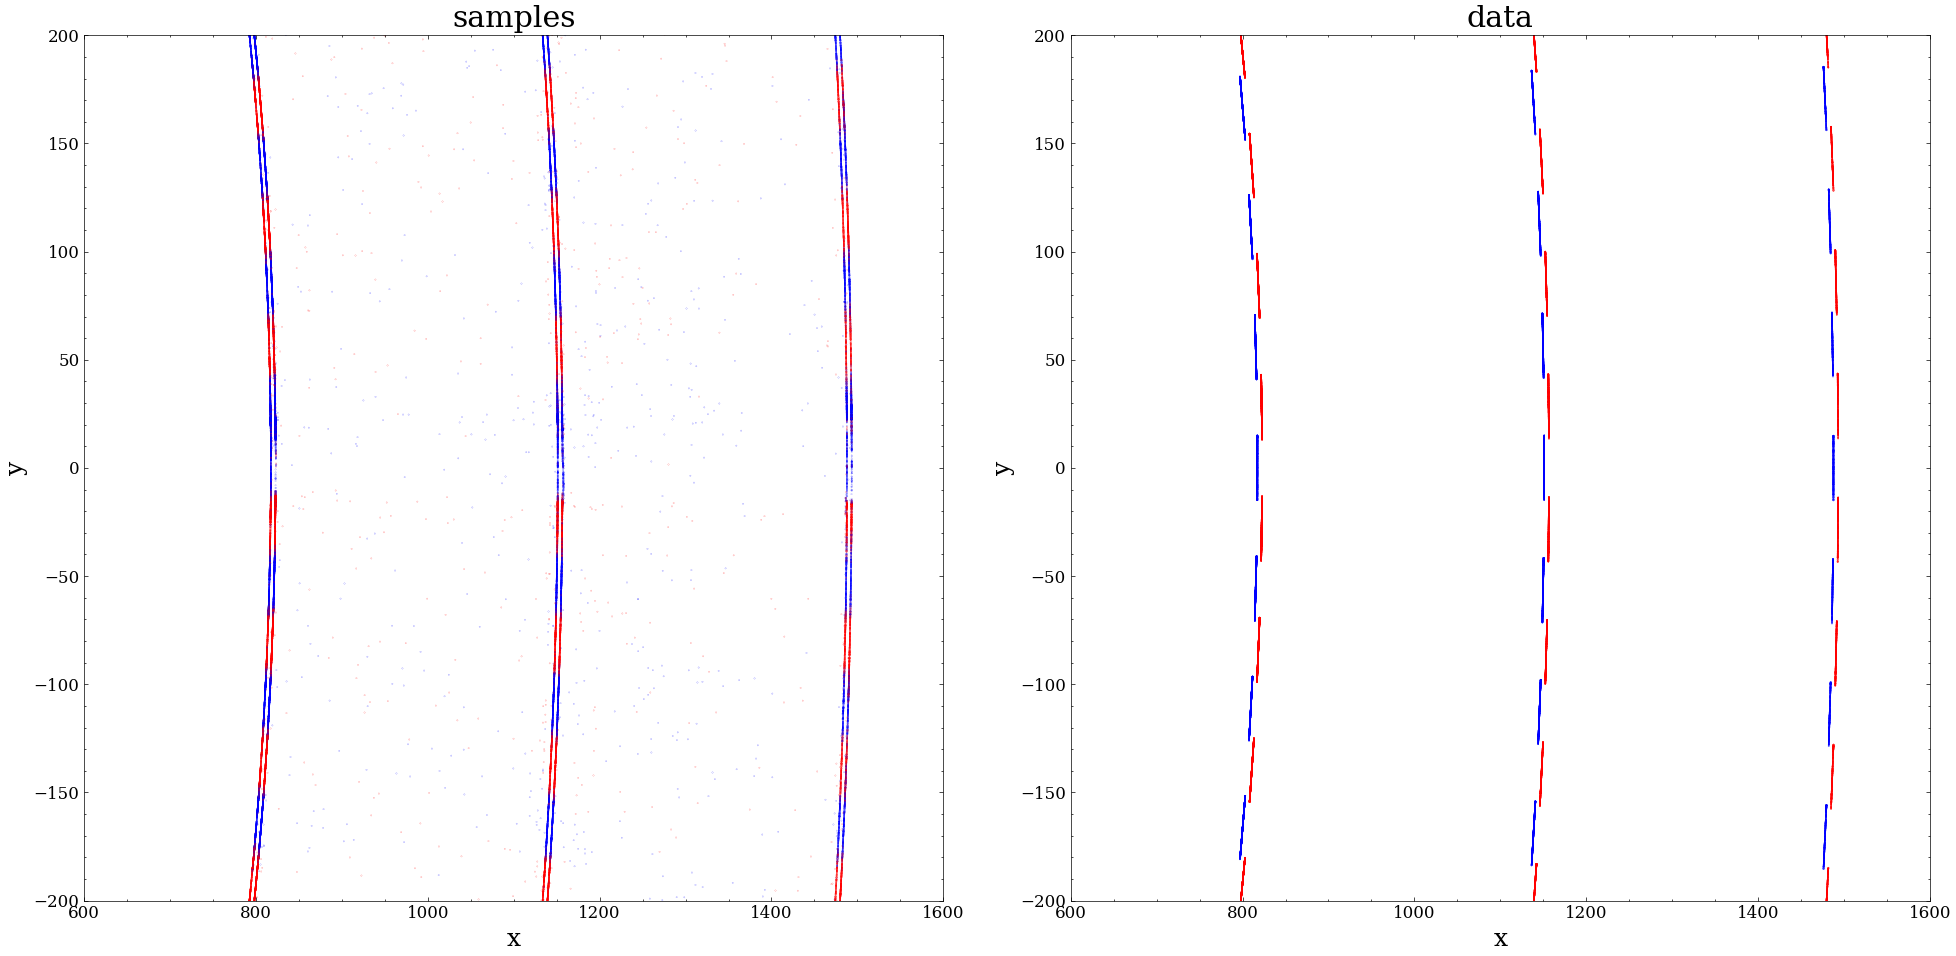

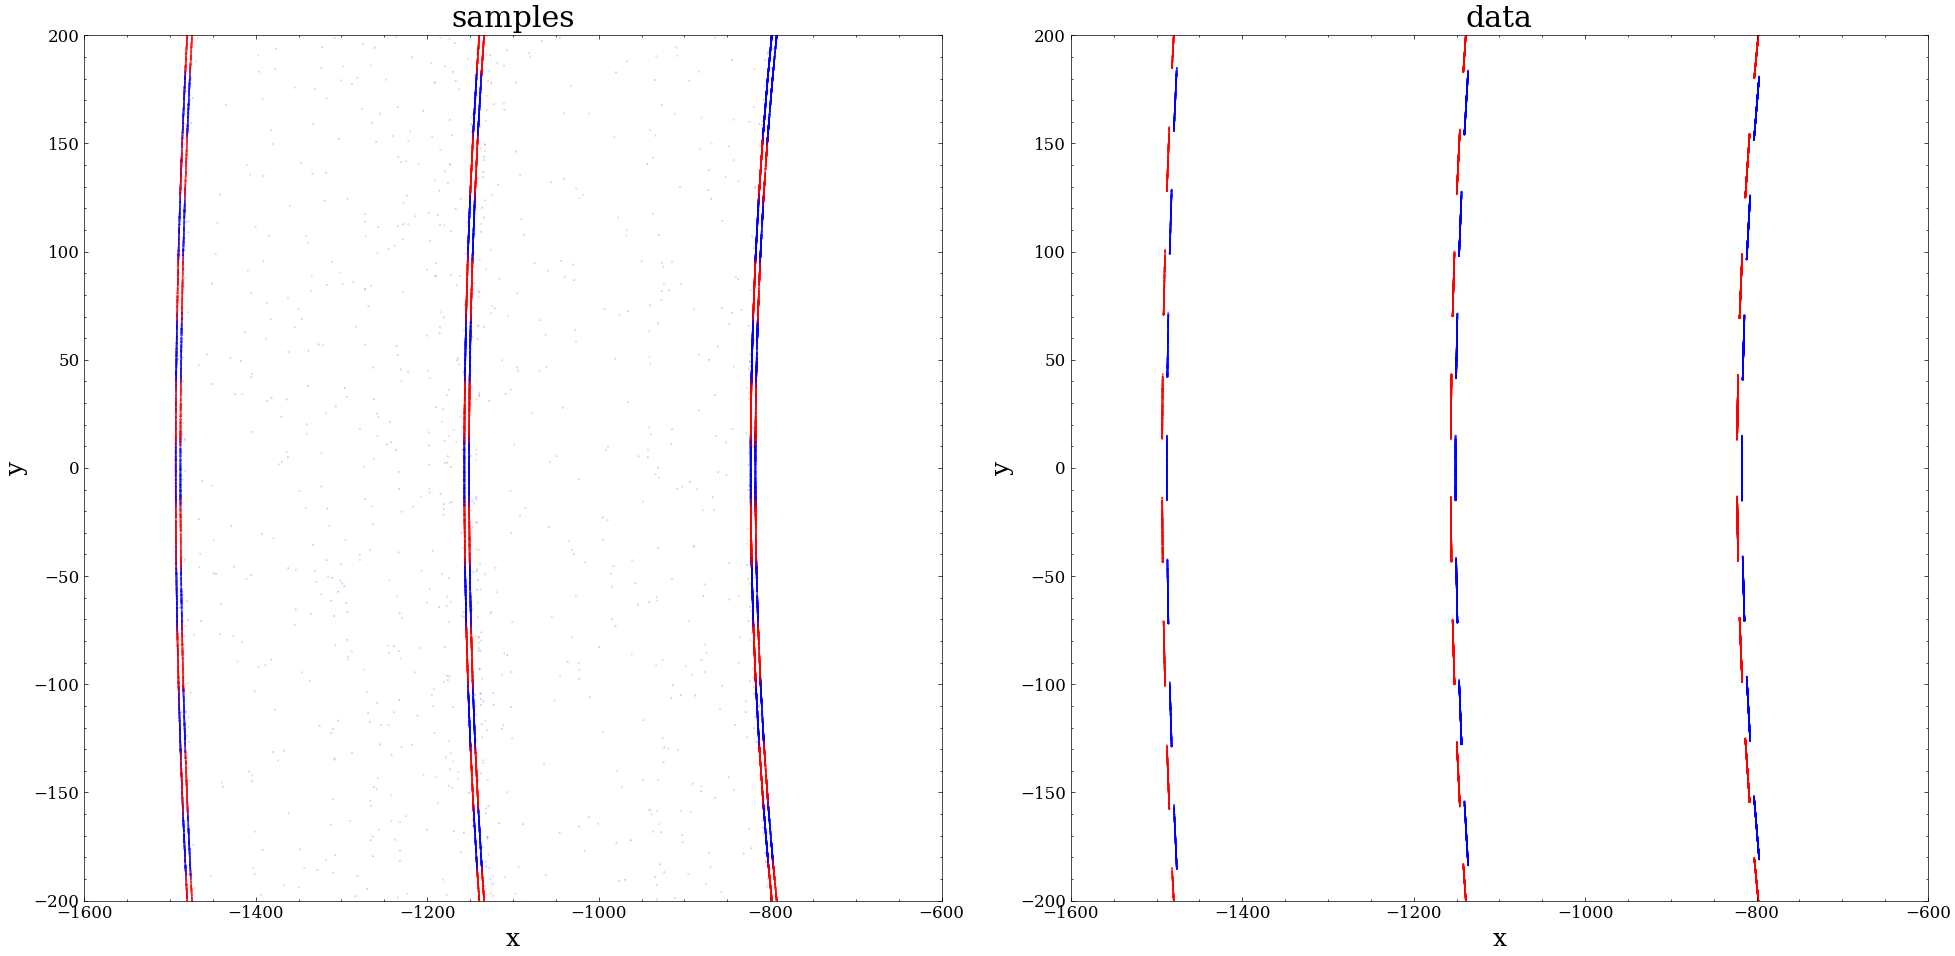

In [5]:
N = 1_000_000  # reduced from 1M for speed

# compute x, y
x      = all_samples_dir[col_name][:N, 2] * np.cos(all_samples_dir[col_name][:N, 3])
y      = all_samples_dir[col_name][:N, 2] * np.sin(all_samples_dir[col_name][:N, 3])
x_data = all_data_dir[col_name][:N, 2] * np.cos(all_data_dir[col_name][:N, 3])
y_data = all_data_dir[col_name][:N, 2] * np.sin(all_data_dir[col_name][:N, 3])

# alternating module colors for contrast
c_s = all_samples_dir[col_name][:N, -2].astype(int) % 2
c_d = all_data_dir[col_name][:N, -2].astype(int) % 2

scatter_kwargs = dict(s=0.01, cmap='bwr', vmin=0, vmax=1)

# --- positive x side ---
fig, ax = plt.subplots(1, 2, figsize=(20, 10))
ax[0].scatter(x,      y,      c=c_s, **scatter_kwargs)
ax[1].scatter(x_data, y_data, c=c_d, **scatter_kwargs)
for a in ax:
    a.set_xlim(600, 1600)
    a.set_ylim(-200, 200)
    a.set_xlabel("x")
    a.set_ylabel("y")
ax[0].set_title("samples")
ax[1].set_title("data")
plt.tight_layout()
plt.show()

# --- negative x side ---
fig, ax = plt.subplots(1, 2, figsize=(20, 10))
ax[0].scatter(x,      y,      c=c_s, **scatter_kwargs)
ax[1].scatter(x_data, y_data, c=c_d, **scatter_kwargs)
for a in ax:
    a.set_xlim(-1600, -600)
    a.set_ylim(-200, 200)
    a.set_xlabel("x")
    a.set_ylabel("y")
ax[0].set_title("samples")
ax[1].set_title("data")
plt.tight_layout()
plt.show()

In [ ]:
plt.hist(all_data_dir[col_name][:,-3])




In [ ]:
layer_mask = all_data_dir[col_name][:,-3] == 0

print(np.max(all_data_dir[col_name][:,-2][layer_mask]))


layer_mask = all_data_dir[col_name][:,-3] == 1

print(np.max(all_data_dir[col_name][:,-2][layer_mask]))


layer_mask = all_data_dir[col_name][:,-3] == 2

print(np.max(all_data_dir[col_name][:,-2][layer_mask]))

